# Geometry vs. reconstruction $\beta$
Plot CCGP/parallelism vs reconstruction loss. 

###### Import statements, setup environment:

In [1]:
import sys
import os
import pathlib 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import json
import re
import inspect
try:
    from analysis_metadata.analysis_metadata import Metadata, write_metadata, increment_dir_name, seconds_2_full_time_str
except ImportError or ModuleNotFoundError:
    analysis_metdata_imported=False

###### Define inputs, parameters:

In [15]:
# Input file:
#input_path = 'E:\\simulation_whiskers\\results\\run651\\ae_iterate_beta_reconstruction.pickle'
input_path = os.path.join('/', 'mnt', 'smb', 'locker', 'issa-locker', 'users', 'Dan', 'code', 'ws', 'results', 'run843', 'iterate_mdl_geo_pipeline.pickle')

# Define independent variable:
X = 'beta_rec'
#X = lambda x : x.beta0 + x.beta1


# Define general filter:
misc_flt = lambda x : x.epoch == max(geo_df_hidden.epoch) if 'epoch' in geo_df_hidden.columns else True 
    

# Plotting parameters:
#xscale = 'linear'
xscale = 'log'
base_color = np.array([0, 0.5, 0])
    
#ccgp_yl = None
#par_yl = None
ccgp_yl = [0.45, 1.0]
par_yl = [-0.4, 1.0]

xlim = None
#xlim = [-200, 5000]

ind_var_lbl = None
# ind_var_lbl = r'$\beta_{0} + \beta_{1}$'


# Output parameters:
save_output = True

##### Load results:

In [16]:
results = pickle.load(open(input_path, 'rb'))
geo_df = results['geo_df']

##### Preliminaries:

In [20]:
# Compute independent variable if necessary:
if callable(X):
    ind_var = geo_df.apply(X, axis=1)
    geo_df['ind_var'] = ind_var
    if ind_var_lbl is None:
        ind_var_lbl = inspect.getsource(X)
elif type(X) == str:
    geo_df['ind_var'] = geo_df[X]
    ind_var_lbl = X
    # Hack; replace 'reconstruction' with 'prediction' if applicable
    if ind_var_lbl=='beta_rec' and 'model_type' in geo_df and np.all(geo_df.model_type=='prediction'):
        ind_var_lbl = 'beta_pred'

if xscale == 'log':
    ind_var_lbl = 'log({})'.format(ind_var_lbl)


# Select layer-specific results:
geo_df_hidden = geo_df[geo_df.layer=='hidden'] 
geo_df_input = geo_df[geo_df.layer=='inpt'] 
    

# Apply any general filters:
geo_df_hidden = geo_df_hidden[geo_df_hidden.apply(misc_flt, axis=1)]
    

# Get dichotomies:
#dichotomy_strs = np.unique(geo_df_hidden.dichotomy)
if 'dichotomy_str' in geo_df_hidden.columns:
    dichotomy_strs = np.unique(geo_df_hidden.dichotomy_str)
else:
    dichotomy_strs = np.unique(geo_df_hidden.apply(lambda x : ' vs '.join(re.findall('\{.*?\}',x.dichotomy)), axis=1))
dichotomy_lines = []
for i, d in enumerate(dichotomy_strs):
    curr_dichotomy_str = 'Task {} : {}'.format(i, d)
    dichotomy_lines.append(curr_dichotomy_str)
dichotomy_lines = '\n'.join(dichotomy_lines)


# Get column name for repeat index depending on whether data is old or new format:
if 'repeat' in geo_df_hidden.columns:
    rep_colname = 'repeat'
else:
    rep_colname = 'repeat_idx'
    
    
# Get number of subsamples/repeats:
n_repeats = len(np.unique(geo_df_hidden[rep_colname]))
repeats_lines = 'n repeats = {}'.format(n_repeats)


# Try to get penalty:
if 'penalty' not in geo_df:
    inpt_dir = os.path.split(input_path)[0]
    metadata_path = os.path.join(inpt_dir, 'iterate_mdl_geo_pipeline.json')
    inpt_metadata = json.load(open(metadata_path, 'rb'))
    try:
        penalty = inpt_metadata['parameters']['autoencoder_params']['p_norm']
    except KeyError:
        penalty = None
else:
    if len(np.unique(geo_df.penalty)) == 1:
        penalty = geo_df.iloc[0].penalty
    else:
        penalty = None


# If plotting different curves for each value of beta_sp, colors should get darker with increasing beta_sp:
if len(np.unique(geo_df.beta_sp)) > 1 and len(np.unique(geo_df.n_hidden)) == 1:
    color_order = 'forward'
else:
    color_order = 'reverse'

    
# Eliminate subsample column if necessary; ended up never using this:
if 'subsample' in geo_df_hidden:
    geo_df_hidden = geo_df_hidden.drop(columns=['subsample'])

<>:32: SyntaxWarning: invalid escape sequence '\{'
<>:32: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipykernel_28171/2151828379.py:32: SyntaxWarning: invalid escape sequence '\{'
  dichotomy_strs = np.unique(geo_df_hidden.apply(lambda x : ' vs '.join(re.findall('\{.*?\}',x.dichotomy)), axis=1))


###### CCGP analysis:

400     functools.partial(<function matches_template a...
401     functools.partial(<function matches_template a...
402     functools.partial(<function matches_template a...
403     functools.partial(<function matches_template a...
404     functools.partial(<function matches_template a...
                              ...                        
9395    functools.partial(<function matches_template a...
9396    functools.partial(<function matches_template a...
9397    functools.partial(<function matches_template a...
9398    functools.partial(<function matches_template a...
9399    functools.partial(<function matches_template a...
Name: train_partition_str, Length: 2400, dtype: object

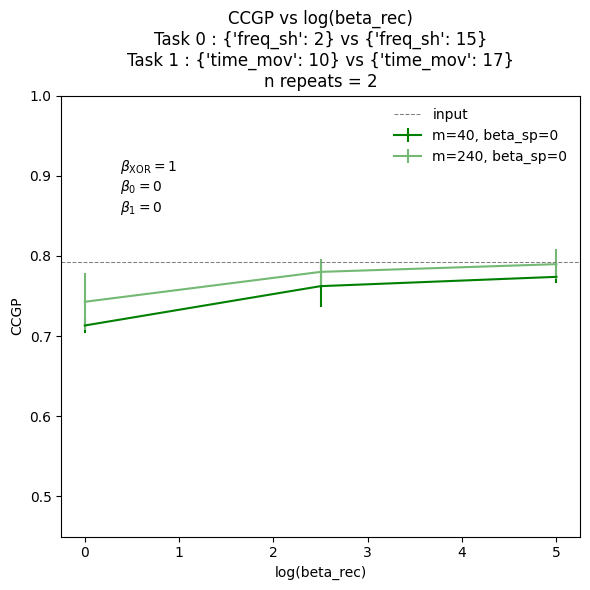

In [28]:
# Compute CCGP means:
Mu = geo_df_hidden[['n_hidden', 'dichotomy_idx', 'train_partition_idx', rep_colname, 'beta_sp', 'ind_var', 'train_accuracy', 'test_accuracy']]\
    .groupby(['n_hidden', 'dichotomy_idx', 'train_partition_idx', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', 'dichotomy_idx', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', 'beta_sp', 'ind_var']).mean().reset_index()

if xscale == 'log':
    Mu['ind_var'] = Mu.apply(lambda x : np.log10(x.ind_var) if x.ind_var>0 else x.ind_var, axis=1)

# Compute CCGP standard deviations:
Std = geo_df_hidden[['n_hidden', 'dichotomy_idx', 'train_partition_idx', rep_colname, 'beta_sp', 'ind_var', 'train_accuracy', 'test_accuracy']]\
    .groupby(['n_hidden', 'dichotomy_idx', 'train_partition_idx', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', 'dichotomy_idx', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', 'beta_sp', 'ind_var']).std().reset_index()

# Compute input CCGP for reference:
Mu_input = geo_df_input[['n_hidden', 'dichotomy_idx', 'train_partition_idx', rep_colname, 'beta_sp', 'ind_var', 'train_accuracy', 'test_accuracy']]\
    .groupby(['n_hidden', 'dichotomy_idx', 'train_partition_idx', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', 'dichotomy_idx', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', 'beta_sp', 'ind_var']).mean()\
    .groupby(['ind_var']).mean().reset_index()
Mu_input = Mu_input.mean(axis=0)

configs = Mu[['n_hidden', 'beta_sp']].drop_duplicates()
configs = configs.reset_index()

# Plot CCGP:
ccgp_fig, ax = plt.subplots(figsize=(6,6))
for i, cfg in configs.iterrows():
    
    is_hls = np.array(Mu.n_hidden == cfg.n_hidden)
    is_sp = np.array(Mu.beta_sp == cfg.beta_sp)
    curr_mu = Mu[is_hls & is_sp]
    curr_std = Std[is_hls & is_sp]
    
    label = 'm={}, beta_sp={}'.format(cfg.n_hidden, cfg.beta_sp)
    if penalty is not None:
        label += ', L{}'.format(int(penalty))
    
    if color_order == 'reverse':        
        curr_color = base_color + 0.9*(i/configs.shape[0])*(np.array([1,1,1]) - base_color)
    elif color_order == 'forward':
        curr_color = 0.9*np.array([1,1,1]) - (i/configs.shape[0])*(np.array([1,1,1]) - base_color)
        
    plt.errorbar(curr_mu['ind_var'], curr_mu.test_accuracy, yerr=curr_std.test_accuracy, color=curr_color, label=label)

# Plot input CCGP for reference:
plt.axhline(y=Mu_input.test_accuracy, color='gray', linewidth=0.75, linestyle='--', label='input')


main_title_line = 'CCGP vs {}'.format(ind_var_lbl)
title = '\n'.join([main_title_line, dichotomy_lines, repeats_lines])
plt.title(title)
plt.ylabel('CCGP')
plt.xlabel(ind_var_lbl)
plt.legend(frameon=False)

if xlim is not None:
    plt.xlim(xlim)

if ccgp_yl is not None:
    plt.ylim(ccgp_yl)

annotation_str = ''
if np.ptp(geo_df.beta_xor) == 0:
    annotation_str += r'$\beta_{\text{XOR}} = $' + '{}'.format(geo_df.iloc[0].beta_xor) + '\n'

if np.ptp(geo_df.beta_rec) == 0:
    annotation_str += r'$\beta_{\text{rec}} = $' + '{}'.format(geo_df.iloc[0].beta_rec) + '\n'
    
if np.ptp(geo_df.beta0) == 0:
    annotation_str += r'$\beta_{0} = $' + '{}'.format(geo_df.iloc[0].beta0) + '\n'

if np.ptp(geo_df.beta1) == 0:
    annotation_str += r'$\beta_{1} = $' + '{}'.format(geo_df.iloc[0].beta1) + '\n'

plt.annotate(annotation_str, [0.2, 0.6], xycoords='figure fraction')
plt.tight_layout()

###### Parallelism analysis:

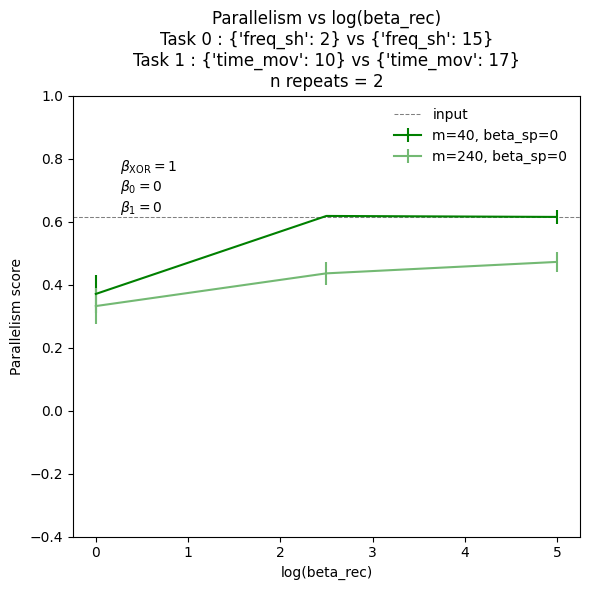

In [43]:
# Compute parallelism means:
Mu = geo_df_hidden[['n_hidden', 'dichotomy_idx', 'train_partition_idx', rep_colname, 'beta_sp', 'ind_var', 'parallelism']]\
    .groupby(['n_hidden', 'dichotomy_idx', 'train_partition_idx', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', 'dichotomy_idx', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', 'beta_sp', 'ind_var']).mean().reset_index()

if xscale == 'log':
    Mu['ind_var'] = Mu.apply(lambda x : np.log10(x.ind_var) if x.ind_var>0 else x.ind_var, axis=1)

# Compute parallelism standard deviations:
Std = geo_df_hidden[['n_hidden', 'dichotomy_idx', 'train_partition_idx', rep_colname, 'beta_sp', 'ind_var', 'parallelism']]\
    .groupby(['n_hidden', 'dichotomy_idx', 'train_partition_idx', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', 'dichotomy_idx', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', 'beta_sp', 'ind_var']).std().reset_index()

# Compute input parallelism for reference:
Mu_input = geo_df_input[['n_hidden', 'dichotomy_idx', 'train_partition_idx', rep_colname, 'beta_sp', 'ind_var', 'parallelism']]\
    .groupby(['n_hidden', 'dichotomy_idx', 'train_partition_idx', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', 'dichotomy_idx', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', rep_colname, 'beta_sp', 'ind_var']).mean()\
    .groupby(['n_hidden', 'beta_sp', 'ind_var']).mean()\
    .groupby(['ind_var']).mean().reset_index()
Mu_input = Mu_input.mean(axis=0)

configs = Mu[['n_hidden', 'beta_sp']].drop_duplicates()
configs = configs.reset_index()

# Plot parallelism:
parallelism_fig, ax = plt.subplots(figsize=(6,6))
for i, cfg in configs.iterrows():
    
    is_hls = np.array(Mu.n_hidden == cfg.n_hidden)  
    is_sp = np.array(Mu.beta_sp == cfg.beta_sp)
    curr_mu = Mu[is_hls & is_sp]
    curr_std = Std[is_hls & is_sp]
    
    label = 'm={}, beta_sp={}'.format(cfg.n_hidden, cfg.beta_sp)
    if penalty is not None:
        label += ', L{}'.format(int(penalty))
    
    if color_order == 'reverse':        
        curr_color = base_color + 0.9*(i/configs.shape[0])*(np.array([1,1,1]) - base_color)
    elif color_order == 'forward':
        curr_color = 0.9*np.array([1,1,1]) - (i/configs.shape[0])*(np.array([1,1,1]) - base_color)
    
    plt.errorbar(curr_mu['ind_var'], curr_mu.parallelism, yerr=curr_std.parallelism, color=curr_color, label=label)

# Plot input parallelism for reference:
plt.axhline(y=Mu_input.parallelism, color='gray', linewidth=0.75, linestyle='--', label='input')


main_title_line = 'Parallelism vs {}'.format(ind_var_lbl)
title = '\n'.join([main_title_line, dichotomy_lines, repeats_lines])
plt.title(title)
plt.ylabel('Parallelism score')
plt.xlabel(ind_var_lbl)
plt.legend(frameon=False)

if xlim is not None:
    plt.xlim(xlim)

if par_yl is not None:
    plt.ylim(par_yl)

annotation_str = ''
if np.ptp(geo_df.beta_xor) == 0:
    annotation_str += r'$\beta_{\text{XOR}} = $' + '{}'.format(geo_df.iloc[0].beta_xor) + '\n'
    
if np.ptp(geo_df.beta_rec) == 0:
    annotation_str += r'$\beta_{\text{rec}} = $' + '{}'.format(geo_df.iloc[0].beta_rec) + '\n'
    
if np.ptp(geo_df.beta0) == 0:
    annotation_str += r'$\beta_{0} = $' + '{}'.format(geo_df.iloc[0].beta0) + '\n'

if np.ptp(geo_df.beta1) == 0:
    annotation_str += r'$\beta_{1} = $' + '{}'.format(geo_df.iloc[0].beta1) + '\n'

plt.annotate(annotation_str, [0.2, 0.6], xycoords='figure fraction')
plt.tight_layout()

###### Save output:

In [11]:
if save_output:
    
    # Define current output directory:
    input_dir = os.path.split(input_path)[0]
    if 'analysis_metadata' in sys.modules:
        curr_output_dir = increment_dir_name(input_dir, 'geometry_vs_hidden_layer_size')
    else: 
        curr_output_dir = os.path.join(input_dir, 'geometry_vs_hidden_layer_size')
    
    # Create current output directory if necessary:
    if not os.path.exists(curr_output_dir):
        pathlib.Path(curr_output_dir).mkdir(parents=True,exist_ok=True)
    
    # Save figures:
    ccgp_fig_basename = 'ccgp_v_beta'
    if xscale == 'log':
        ccgp_fig_basename += '_log'
    plt.figure(ccgp_fig)
    ccgp_png_path = os.path.join(curr_output_dir, ccgp_fig_basename+'.png')
    plt.savefig(ccgp_png_path)
    ccgp_svg_path = os.path.join(curr_output_dir, ccgp_fig_basename+'.svg')
    plt.savefig(ccgp_svg_path)
    
    par_fig_basename = 'parallelism_v_beta'
    if xscale == 'log':
        par_fig_basename += '_log'
    plt.figure(parallelism_fig)
    parallelism_png_path = os.path.join(curr_output_dir, par_fig_basename+'.png')
    plt.savefig(parallelism_png_path)
    parallelism_svg_path = os.path.join(curr_output_dir, par_fig_basename+'.svg')
    plt.savefig(parallelism_svg_path)
    
    # Save metadata:
    if 'analysis_metadata' in sys.modules:
        
        M = Metadata()
        M.add_input(input_path)
        M.add_output(ccgp_png_path)
        M.add_output(ccgp_svg_path)
        M.add_output(parallelism_png_path)
        M.add_output(parallelism_svg_path)
        metadata_path = os.path.join(curr_output_dir, 'geometry_vs_beta.json')
        write_metadata(M, metadata_path)

Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run755/ae_iterate_beta_reconstruction.pickle...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run755/geometry_vs_hidden_layer_size001/ccgp_v_beta_log.png...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run755/geometry_vs_hidden_layer_size001/ccgp_v_beta_log.svg...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run755/geometry_vs_hidden_layer_size001/parallelism_v_beta_log.png...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run755/geometry_vs_hidden_layer_size001/parallelism_v_beta_log.svg...


In [44]:
geo_df.columns

Index(['dichotomy', 'train_partition', 'train_accuracy', 'test_accuracy',
       'parallelism', 'hparams_idx', 'mdl_id', 'layer', 'epoch',
       'dichotomy_idx', 'dichotomy_str', 'train_partition_idx',
       'train_partition_str', 'index', 'task_defs', 'xor', 'n_geo_subsamples',
       'zscore_data', 'save_perf', 'sum_inpt', 'chunked_reconstruction_loss',
       'save_learning', 'gpu', 'save_sessions', 'verbose', 'concavity',
       'n_whisk', 'prob_poiss', 'noise_w', 'spread', 'speed', 'ini_phase_m',
       'ini_phase_spr', 'delay_time', 'freq_m', 'freq_std', 'std_reset',
       't_total', 'dt', 'dx', 'n_trials_pre', 'amp', 'freq_sh', 'z1',
       'max_rad', 'n_rad', 'disp', 'theta', 'steps_mov', 'rad_vec',
       'init_position', 'mdl_type', 'n_hidden', 'sig_init', 'sig_neu', 'lr',
       'beta0', 'beta1', 'beta_rec', 'beta_xor', 'beta_sp', 'beta_pr',
       'n_epochs', 'batch_size', 'p_norm', 'n_splits', 'n_predictor_bins',
       'n_predicted_bins', 'n_offsets', 'repeat_idx', 'ta

In [45]:
np.unique(geo_df.hparams_idx)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [46]:
rep_colname

'repeat_idx'

In [52]:
foo

NameError: name 'foo' is not defined

In [54]:
Mu_geo_in = geo_df_in[['hparams_idx', 'dichotomy', 'train_partition', 'repeat_idx', 'parallelism']]\
.groupby(['hparams_idx', 'dichotomy', 'train_partition', 'repeat_idx']).mean()\
.groupby(['hparams_idx', 'dichotomy', 'train_partition']).mean()\
.groupby(['hparams_idx', 'dichotomy']).mean()\
.groupby(['hparams_idx']).mean().reset_index()

In [56]:
Mu_geo_in.mean()

hparams_idx    5.500000
parallelism    0.613511
dtype: float64

In [57]:
np.mean(geo_df_in.parallelism)

np.float64(0.6135112648177116)